#  Linear regression

In this part of this exercise, you will implement linear regression with one
variable to predict profits for a food truck. Suppose you are the CEO of a
restaurant franchise and are considering different cities for opening a new
outlet. The chain already has trucks in various cities and you have data for
profits and populations from the cities.

The file ex1data1.txt contains the dataset for our linear regression problem. The first column is the population of a city and the second column is
the profit of a food truck in that city. A negative value for profit indicates a
loss

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Load data
data = np.loadtxt('ex1data1.txt', delimiter=',')  # Load the text file with a comma as a delimiter
print(data[0:5,:])
#load the data a create a np vectors X and y

[[ 6.1101 17.592 ]
 [ 5.5277  9.1302]
 [ 8.5186 13.662 ]
 [ 7.0032 11.854 ]
 [ 5.8598  6.8233]]


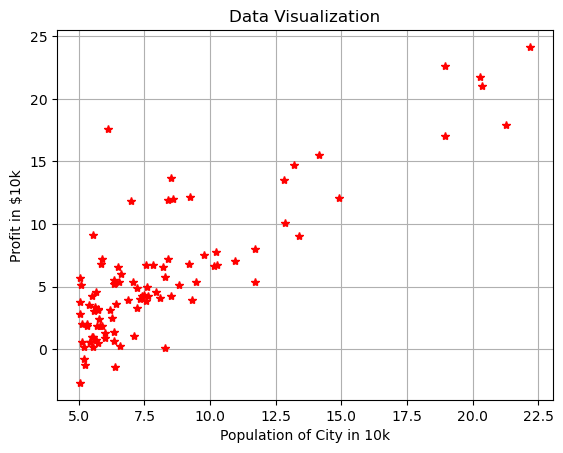

In [5]:
# ==================== Part 1: Plotting ====================
X = data[:, 0].reshape(-1,1)  # First column is the population
y = data[:, 1].reshape(-1,1)  # Second column is the profit
del data
# Plot data
plt.plot(X, y, '*r', label='Profit')  # Red stars for positive examples
plt.grid(True)  # Turn on the grid
#plt.legend()    # Add legend
plt.xlabel('Population of City in 10k')  # Label for x-axis
plt.ylabel('Profit in $10k')  # Label for y-axis
plt.title('Data Visualization')  # Add a title
plt.show()

# Cost Function

The objective of linear regression is to minimize the cost function:
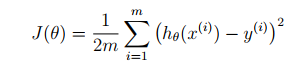

where the hypothesis h is given by

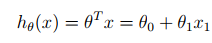

**Create a matrix by adding a column of ones to the vecto X**

You should expect to see a cost of approximately 32.07


In [6]:
#Implement cost function
def hypothesis(theta, X):
    return X @ theta
def cost_function(theta, X, y):
    m = len(y)
    h = hypothesis(theta, X)
    error = y-h
    J = (1 / (2 * m)) * error.T @ error
    return J.item()
m = y.shape[0]
X_ = np.hstack([np.ones((m, 1)), X])
del X
theta_0 = np.zeros((2, 1)) # Look that theta is a vector 2x1
print(f"Model parameters: {theta_0}")
print(f"Cost function: {cost_function(theta_0, X_, y)}") #You should expect to see a cost of approximately 32.07


Model parameters: [[0.]
 [0.]]
Cost function: 32.07273387745567


# Gradient descent

Next, you will implement gradient descent in the file gradientDescent.m.
The loop structure has been written for you, and you only need to supply
the updates to θ within each iteration.

Using the following values:
iterations = 3
theta = np.zeros((2, 1))
alpha = 0.01

The first three iteration:

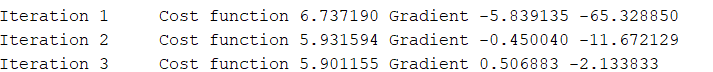



In [ ]:
def gradientDescent(X, y, theta, alpha, iterations):
    m = len(y)  
    J_history = np.zeros(iterations)
    theta_history = np.zeros((iterations, theta.shape[0]))
    
    for iter in range(iterations):
        gradients = 1/m * X.T @ (X @ theta - y)
        theta_history[iter] = theta.flatten()
        theta = theta - alpha * gradients
        J_history[iter] = cost_function(theta, X, y)
        if iter % 50 == 0:
            print(f"Iteration {iter + 1}\tCost: {J_history[iter]:.6f}\tGradient: {gradients.ravel()}")
    
    if iterations < 10:
        return theta
    else:
        return theta, J_history, theta_history

In [8]:
iterations = 3
alpha = 0.01
theta= gradientDescent(X_, y, theta_0, alpha, iterations);
print("Theta found by gradient descent: ", theta)

Iteration 1	Cost: 6.737190	Gradient: [ -5.83913505 -65.32884975]
Theta found by gradient descent:  [[0.05782293]
 [0.79134812]]


For population = 50,000, we predict a profit of 40145.64
For population = 35,000, we predict a profit of 55972.60


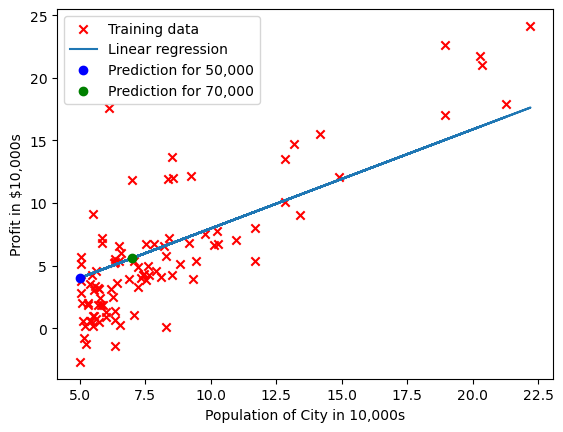

In [9]:
# Predict values for population sizes of 50,000 and 70,000
predict1 = np.array([1, 5]) @ theta
print(f'For population = 50,000, we predict a profit of {(predict1 * 10000).item():.2f}')
predict2 = np.array([1, 7.0]) @ theta
print(f'For population = 35,000, we predict a profit of {(predict2 * 10000).item():.2f}')
# Plot the linear fit
plt.scatter(X_[:,1:], y, color='red', marker='x', label='Training data')  # X[:,1] is the feature (since X[:,0] is the bias term)
plt.plot(X_[:,1:], X_@ theta, label='Linear regression')  # X @ theta gives the predicted values
plt.xlabel('Population of City in 10,000s')
plt.ylabel('Profit in $10,000s')
plt.plot(5, predict1.item(), 'ob', label='Prediction for 50,000')
plt.plot(7.0, predict2.item(), 'og', label='Prediction for 70,000')
plt.legend()
plt.show()
del predict1
del predict2

# Visualization

In [10]:
theta, j, th= gradientDescent(X_, y, theta_0, alpha, 300);
print(theta)

Iteration 1	Cost: 6.737190	Gradient: [ -5.83913505 -65.32884975]
Iteration 51	Cost: 5.673965	Gradient: [ 0.65480683 -0.06578245]
Iteration 101	Cost: 5.476363	Gradient: [ 0.59832205 -0.06010794]
Iteration 151	Cost: 5.311381	Gradient: [ 0.54670974 -0.05492292]
Iteration 201	Cost: 5.173635	Gradient: [ 0.49954961 -0.05018518]
Iteration 251	Cost: 5.058628	Gradient: [ 0.45645759 -0.04585612]
[[-1.58199122]
 [ 0.96058838]]


Visualizing J(theta_0, theta_1) ...


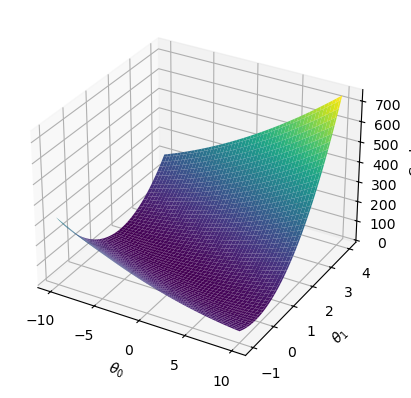

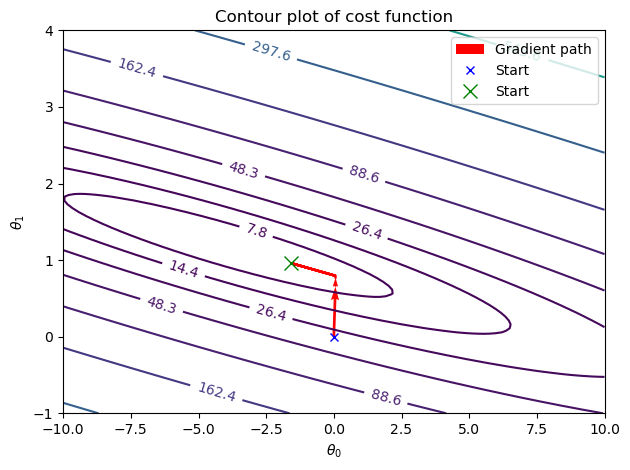

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plots
print('Visualizing J(theta_0, theta_1) ...')
theta_init = np.zeros((2, 1))
theta0_vals = np.linspace(-10, 10, 100)
theta1_vals = np.linspace(-1, 4, 100)
J_vals = np.zeros((len(theta0_vals), len(theta1_vals)))

for i in range(len(theta0_vals)):
    for j in range(len(theta1_vals)):
        t = np.array([[theta0_vals[i]], [theta1_vals[j]]])
        J_vals[i, j] = cost_function(t, X_, y)

# Transpose J_vals to match the orientation of MATLAB's surf
J_vals = J_vals.T

# Surface plot
theta0_vals_mesh, theta1_vals_mesh = np.meshgrid(theta0_vals, theta1_vals)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(theta0_vals_mesh, theta1_vals_mesh, J_vals, cmap='viridis')
ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')
ax.set_zlabel('Cost', rotation=90)

plt.figure()
cp = plt.contour(theta0_vals, theta1_vals, J_vals, levels=np.logspace(-2, 3, 20))
plt.clabel(cp)
plt.xlabel(r'$\theta_0$')
plt.ylabel(r'$\theta_1$')
theta1_path = th[:, 0]
theta2_path = th[:, 1]
u = theta1_path[1:] - theta1_path[:-1]
v = theta2_path[1:] - theta2_path[:-1]
plt.quiver(theta1_path[:-1], theta2_path[:-1], u, v, 
           angles='xy', scale_units='xy', scale=1, color='red', width=0.005, label='Gradient path')
plt.plot(theta1_path[0], theta2_path[0], 'bx', label='Start')
plt.plot(theta[0, 0], theta[1, 0], 'gx', markersize=10, linewidth=2,label='Start')
plt.title('Contour plot of cost function')
plt.grid(False)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()
